# Statistical Mechanics: Ensembles, the Microcanonical Ensemble, and the Canonical Ensemble

This lesson covers the first few sections of Chapter 3 of Chandler, *Introduction to Modern Statistical Mechanics*.

The central transition is:

**Thermodynamics tells us what equilibrium macrostates do. Statistical mechanics explains why, by assigning probabilities to microscopic states.**


## Learning Goals

After this minute lesson, students will be able to:

1. Distinguish a microscopic state from a macroscopic thermodynamic state.
2. Explain the idea of an ensemble and the difference between time averages and ensemble averages.
3. State the microcanonical postulate: all accessible microstates with fixed $E$, $V$, and $N$ are equally likely.
4. Define the number of accessible states, $\Omega(N,V,E)$, and connect it to entropy:

\begin{equation}
S = k_B \ln \Omega(N,V,E)
\end{equation}

5. Explain how the second law emerges statistically from counting microstates.
6. Derive the Boltzmann distribution for a system in contact with a heat bath.
7. Define the canonical partition function:

\begin{equation}
Q(\beta,N,V)=\sum_\nu e^{-\beta E_\nu}
\end{equation}

8. Use $Q$ to compute probabilities and average energy in a simple model.


## Coding Concepts

The following coding concepts are used in this notebook:

1. [Variables](../../coding_concepts/variables.ipynb)
2. [Functions](../../coding_concepts/functions.ipynb)
3. [Arrays with NumPy](../../coding_concepts/numpy_arrays.ipynb)
4. [Plotting with matplotlib](../../coding_concepts/plotting_with_matplotlib.ipynb)

The code is intended to support physical intuition. The statistical mechanical ideas are the main focus.


## From Thermodynamics to Statistical Mechanics

In Chapters 1 and 2, we described equilibrium using macroscopic thermodynamic variables such as $E$, $S$, $V$, $T$, $p$, and $\mu$.

But a real molecular system is described microscopically by many more variables. For a classical system of $N$ particles, a microscopic state is specified by positions and momenta:

\begin{equation}
\Gamma = (\mathbf{r}_1,\ldots,\mathbf{r}_N,\mathbf{p}_1,\ldots,\mathbf{p}_N)
\end{equation}

A trajectory is a path through this high-dimensional state space.

The goal of statistical mechanics is to replace an impossible deterministic calculation with a probabilistic one.


## Microstates and Macrostates

A **microstate** is a detailed microscopic specification of the system.

A **macrostate** is specified by a much smaller number of variables, such as $E$, $V$, and $N$.

Many microstates can correspond to the same macrostate. For example, an ideal gas with fixed $E$, $V$, and $N$ can have many different arrangements of positions and momenta.

The central statistical mechanical question is:

**Given a macrostate, how should we assign probabilities to the compatible microstates?**


## Time Averages and Ensemble Averages

Suppose we measure an observable $G$ many times along a trajectory. A time average has the form

\begin{equation}
G_{\mathrm{obs}} = \frac{1}{M}\sum_{a=1}^{M}G_a
\end{equation}

Statistical mechanics replaces this with an ensemble average:

\begin{equation}
\langle G \rangle = \sum_\nu P_\nu G_\nu
\end{equation}

where $P_\nu$ is the probability of microscopic state $\nu$.

The assumption that time averages and ensemble averages agree is related to **ergodicity**.


## Demonstration: Time Average Approaching an Ensemble Average

The code below simulates a simple trajectory among discrete states. Each state has a value $G_\nu$.

As the trajectory samples the states, the running time average approaches the ensemble average.


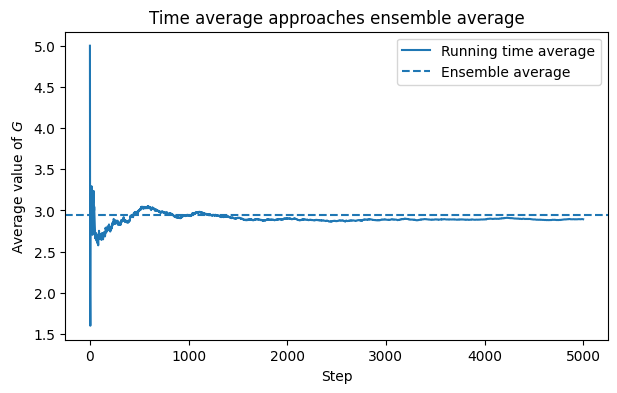

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(123)

# A simple set of states with assigned observable values
G_states = np.array([0.0, 1.0, 2.0, 5.0, 8.0])
P_states = np.array([0.10, 0.20, 0.35, 0.25, 0.10])
P_states = P_states / P_states.sum()

n_steps = 5000
visited_states = rng.choice(len(G_states), size=n_steps, p=P_states)
G_traj = G_states[visited_states]

running_average = np.cumsum(G_traj) / np.arange(1, n_steps + 1)
ensemble_average = np.sum(P_states * G_states)

plt.figure(figsize=(7, 4))
plt.plot(running_average, label="Running time average")
plt.axhline(ensemble_average, linestyle="--", label="Ensemble average")
plt.xlabel("Step")
plt.ylabel("Average value of $G$")
plt.title("Time average approaches ensemble average")
plt.legend()
plt.show()


### Discussion:

1. What assumption is being made when we replace a time average by an ensemble average?
2. What could go wrong in a molecular simulation that does not sample all important regions of state space?
3. How is this related to rare conformational transitions in protein simulations?


# Part 1: The Microcanonical Ensemble

The microcanonical ensemble describes an isolated system with fixed:

\begin{equation}
E, \qquad V, \qquad N
\end{equation}

The statistical postulate is:

**All accessible microscopic states consistent with fixed $E$, $V$, and $N$ are equally likely.**

If there are $\Omega(N,V,E)$ accessible microstates, then

\begin{equation}
P_\nu = \frac{1}{\Omega(N,V,E)}
\end{equation}

for states $\nu$ in the ensemble, and $P_\nu=0$ for inaccessible states.


## Entropy as Counting

Chandler defines entropy statistically as

\begin{equation}
S = k_B \ln \Omega(N,V,E)
\end{equation}

This formula explains why entropy is extensive.

If two independent subsystems have numbers of states $\Omega_A$ and $\Omega_B$, then the combined system has

\begin{equation}
\Omega_{A+B}=\Omega_A\Omega_B
\end{equation}

Therefore,

\begin{align}
S_{A+B}
&= k_B \ln(\Omega_A\Omega_B) \\\\
&= k_B \ln \Omega_A + k_B \ln \Omega_B \\\\
&= S_A + S_B
\end{align}

The logarithm turns multiplication of microscopic possibilities into addition of entropy.


## Demonstration: A Two-State Spin Model

Consider $N$ independent spins. Each spin can be in one of two states. If $n$ spins are excited, the energy is

\begin{equation}
E = n\epsilon
\end{equation}

The number of microstates with this energy is

\begin{equation}
\Omega(n)=\binom{N}{n}
\end{equation}

The entropy is therefore

\begin{equation}
S(n)=k_B\ln\binom{N}{n}
\end{equation}


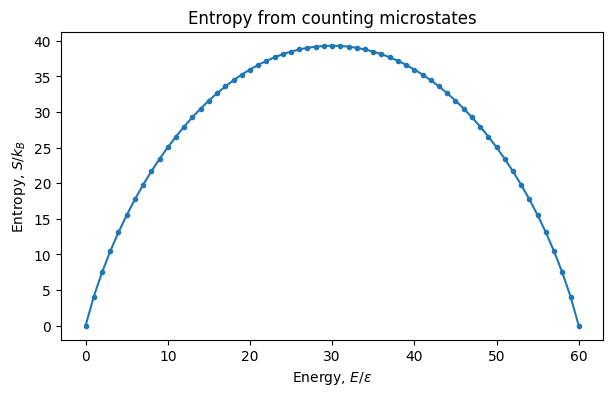

In [2]:
from math import comb

N = 60
n_excited = np.arange(N + 1)
Omega = np.array([comb(N, int(n)) for n in n_excited], dtype=float)
S_over_kB = np.log(Omega)
E_over_epsilon = n_excited

plt.figure(figsize=(7, 4))
plt.plot(E_over_epsilon, S_over_kB, marker="o", markersize=3)
plt.xlabel("Energy, $E/\\epsilon$")
plt.ylabel("Entropy, $S/k_B$")
plt.title("Entropy from counting microstates")
plt.show()


### Discussion:

1. For what value of $n$ is $\Omega(n)$ largest?
2. Why does this macrostate dominate the equilibrium behavior for large $N$?
3. Does the most probable macrostate have the lowest energy?
4. What does this example teach us about entropy maximization?


## Temperature from the Slope of Entropy

Thermodynamics defines temperature through

\begin{equation}
\left(\frac{\partial S}{\partial E}\right)_{N,V}=\frac{1}{T}
\end{equation}

Using $S=k_B\ln\Omega$, this becomes

\begin{equation}
\beta = \frac{1}{k_B T}
= \left(\frac{\partial \ln \Omega}{\partial E}\right)_{N,V}
\end{equation}

Thus temperature is determined by how rapidly the number of accessible microstates grows with energy.


## Important Subtlety: Negative Temperature

For ordinary macroscopic systems, $\Omega(N,V,E)$ usually increases with $E$, so $T>0$.

But for systems with an upper bound on energy, such as a collection of spins in a magnetic field, $\\Omega$ can eventually decrease as energy increases.

In that case,

\begin{equation}
\left(\frac{\partial \ln \Omega}{\partial E}\right)_{N,V}<0
\end{equation}

and the formal temperature is negative.

This is not colder than zero. It is hotter than any positive temperature, because adding energy decreases entropy.


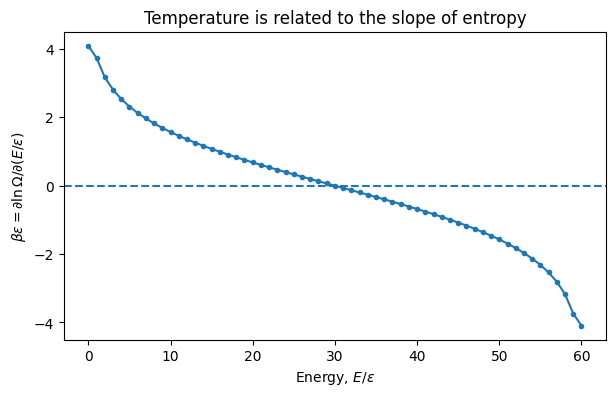

In [3]:
# Estimate beta from the numerical derivative of S/kB with respect to E/epsilon
# This gives beta * epsilon, since beta = d ln(Omega) / dE.

dS_dE = np.gradient(S_over_kB, E_over_epsilon)

plt.figure(figsize=(7, 4))
plt.plot(E_over_epsilon, dS_dE, marker="o", markersize=3)
plt.axhline(0.0, linestyle="--")
plt.xlabel("Energy, $E/\\epsilon$")
plt.ylabel("$\\beta \\epsilon = \\partial \\ln \\Omega / \\partial (E/\\epsilon)$")
plt.title("Temperature is related to the slope of entropy")
plt.show()


# Part 2: The Canonical Ensemble

The microcanonical ensemble applies naturally to an isolated system.

Most chemical systems are not isolated. They exchange energy with their surroundings and are more naturally described at fixed:

\begin{equation}
T, \qquad V, \qquad N
\end{equation}

This leads to the canonical ensemble.

The system energy is allowed to fluctuate, but the temperature is fixed by contact with a heat bath.


## Deriving the Boltzmann Distribution

Imagine a small system in state $\nu$ with energy $E_\nu$, in contact with a large heat bath.

The total energy is fixed:

\begin{equation}
E_{\mathrm{tot}} = E_{\mathrm{bath}} + E_\nu
\end{equation}

If the system has energy $E_\nu$, the bath has energy

\begin{equation}
E_{\mathrm{bath}} = E_{\mathrm{tot}} - E_\nu
\end{equation}

The probability of the system being in state $\nu$ is proportional to the number of bath states compatible with that energy:

\begin{equation}
P_\nu \propto \Omega_{\mathrm{bath}}(E_{\mathrm{tot}}-E_\nu)
\end{equation}


## Taylor Expansion of the Bath Entropy

Write the probability in terms of the logarithm:

\begin{equation}
P_\nu \propto \exp\left[\ln \Omega_{\mathrm{bath}}(E_{\mathrm{tot}}-E_\nu)\right]
\end{equation}

For a very large bath, $E_\nu$ is small compared to $E_{\mathrm{tot}}$, so expand:

\begin{equation}
\ln \Omega_{\mathrm{bath}}(E_{\mathrm{tot}}-E_\nu)
\approx
\ln \Omega_{\mathrm{bath}}(E_{\mathrm{tot}})
-
E_\nu
\left(\frac{\partial \ln \Omega}{\partial E}\right)_{\mathrm{bath}}
\end{equation}

Using

\begin{equation}
\left(\frac{\partial \ln \Omega}{\partial E}\right)_{\mathrm{bath}}
=\beta
\end{equation}

we obtain

\begin{equation}
P_\nu \propto e^{-\beta E_\nu}
\end{equation}

This is the Boltzmann distribution.


## The Canonical Partition Function

Normalization requires

\begin{equation}
\sum_\nu P_\nu = 1
\end{equation}

Therefore,

\begin{equation}
P_\nu = \frac{e^{-\beta E_\nu}}{Q}
\end{equation}

where

\begin{equation}
Q(\beta,N,V)=\sum_\nu e^{-\beta E_\nu}
\end{equation}

is the canonical partition function.

The partition function is the normalization constant, but it is also much more: it contains the thermodynamics of the system.


## Ensemble Averages in the Canonical Ensemble

For any observable $G$, the canonical ensemble average is

\begin{equation}
\langle G \rangle = \sum_\nu P_\nu G_\nu
\end{equation}

In particular, the average energy is

\begin{align}
\langle E \rangle
&=\sum_\nu P_\nu E_\nu \\\\
&=\frac{\sum_\nu E_\nu e^{-\beta E_\nu}}{\sum_\nu e^{-\beta E_\nu}}
\end{align}

This can be written compactly as

\begin{equation}
\langle E \rangle = -\left(\frac{\partial \ln Q}{\partial \beta}\right)_{N,V}
\end{equation}


## Demonstration: A Two-Level System in the Canonical Ensemble

Consider one particle with two possible energies:

\begin{equation}
E_0=0, \qquad E_1=\epsilon
\end{equation}

The partition function is

\begin{equation}
Q = 1 + e^{-\beta\epsilon}
\end{equation}

The probability of the excited state is

\begin{equation}
P_1 = \frac{e^{-\beta\epsilon}}{1+e^{-\beta\epsilon}}
\end{equation}


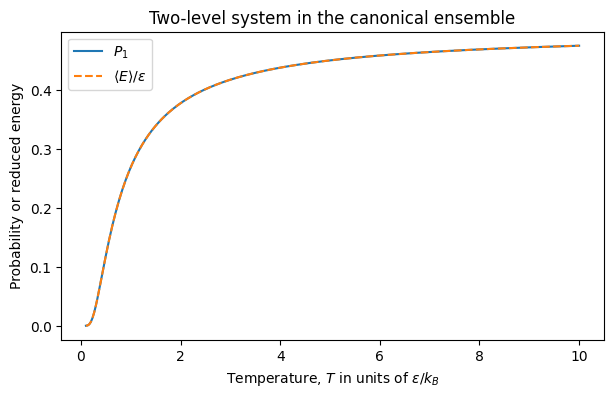

In [4]:
# Work in units where epsilon = 1 and kB = 1.

T = np.linspace(0.1, 10.0, 300)
beta = 1.0 / T
epsilon = 1.0

Q = 1.0 + np.exp(-beta * epsilon)
P_excited = np.exp(-beta * epsilon) / Q
E_avg = epsilon * P_excited

plt.figure(figsize=(7, 4))
plt.plot(T, P_excited, label="$P_1$")
plt.plot(T, E_avg / epsilon, linestyle="--", label="$\\langle E \\rangle/\\epsilon$")
plt.xlabel("Temperature, $T$ in units of $\\epsilon/k_B$")
plt.ylabel("Probability or reduced energy")
plt.title("Two-level system in the canonical ensemble")
plt.legend()
plt.show()


### Discussion Prompt

1. What happens to $P_1$ as $T\rightarrow 0$?
2. What happens to $P_1$ as $T\rightarrow \infty$?
3. Why does the average energy approach $\epsilon/2$ at high temperature?
4. How would the result change if the excited state were degenerate?


## Free Energy Preview

Chandler notes that $\ln Q$ behaves like a thermodynamic function.

The connection is the Helmholtz free energy:

\begin{equation}
A = -k_B T \ln Q
\end{equation}

This is one of the most important bridges between microscopic statistical mechanics and macroscopic thermodynamics.

Once $Q$ is known, thermodynamic quantities can be obtained from derivatives of $A$.


## Summary

The first few sections of Chapter 3 introduce the statistical foundation of thermodynamics.

The key ideas are:

1. A microscopic state contains far more information than a thermodynamic macrostate.
2. An ensemble is a probability distribution over microstates.
3. The microcanonical ensemble assigns equal probability to all states with fixed $E$, $V$, and $N$.
4. Entropy is the logarithm of the number of accessible states:

\begin{equation}
S = k_B \ln \Omega
\end{equation}

5. The second law becomes a statement about counting: equilibrium corresponds to the macrostate compatible with the largest number of microstates.
6. A system in contact with a heat bath has probabilities

\begin{equation}
P_\nu = \frac{e^{-\beta E_\nu}}{Q}
\end{equation}

7. The canonical partition function is

\begin{equation}
Q=\sum_\nu e^{-\beta E_\nu}
\end{equation}

and it encodes the thermodynamics.


## End-of-Class Check

Students should be able to answer these questions without notes:

1. What is the difference between a microstate and a macrostate?
2. What is an ensemble average?
3. What is the microcanonical ensemble?
4. Why does $S=k_B\ln\Omega$ make entropy extensive?
5. Why does removing an internal constraint increase entropy?
6. Why does a system in contact with a heat bath have probabilities proportional to $e^{-\beta E_\nu}$?
7. What is the canonical partition function?
8. How do you compute $\langle E\rangle$ from $Q$?


## Instructor Notes

For a one hour lecture, the most important derivation to do live is the canonical distribution:

\begin{equation}
P_\nu \propto \Omega_{\mathrm{bath}}(E_{\mathrm{tot}}-E_\nu)
\rightarrow
P_\nu \propto e^{-\beta E_\nu}
\end{equation}

This derivation helps students see that the Boltzmann factor is not arbitrary. It comes from applying the microcanonical ensemble to a larger isolated system.

If time is short, skip the negative-temperature discussion and use it as a thought question or homework prompt.
